# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.

### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.

### Imports

We import all libraries used throughout the analysis up front.

In [24]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)

import time
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

**Answer:** According to the *Materials and Methods* section of Moro, Cortez & Rita (2014), the data was collected from **17 telemarketing campaigns** run by a Portuguese retail bank between **May 2008 and November 2010**.  These 17 campaigns together produced **41,188 phone contacts** (the rows in `bank-additional-full.csv`), and the goal of each campaign was to get clients to subscribe to a long-term bank **term deposit**.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [25]:
# The file is semicolon-separated
bank = pd.read_csv('data/bank-additional-full.csv', sep=';')
print(f'Dataset shape: {bank.shape[0]:,} rows x {bank.shape[1]} columns')

Dataset shape: 41,188 rows x 21 columns


In [26]:
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```

In [27]:
# Structure and dtypes
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [28]:
# Check for explicit NaN values
print('Explicit NaN values per column:')
print(bank.isna().sum().sum(), 'total NaN values found')

Explicit NaN values per column:
0 total NaN values found


In [29]:
# Missing data in this dataset is coded as the string 'unknown' rather than NaN.
# Count 'unknown' per column.
unknown_counts = (bank == 'unknown').sum()
unknown_counts = unknown_counts[unknown_counts > 0].sort_values(ascending=False)
print("Columns containing 'unknown' (hidden missing values):")
print(unknown_counts)

Columns containing 'unknown' (hidden missing values):
default      8597
education    1731
housing       990
loan          990
job           330
marital        80
dtype: int64


In [30]:
# 'pdays' uses 999 as a sentinel meaning 'never previously contacted'.
print("Share of rows where pdays == 999 (never previously contacted):",
      round((bank['pdays'] == 999).mean(), 4))

Share of rows where pdays == 999 (never previously contacted): 0.9632


**Observations on data quality / types**

- **No explicit `NaN` values.** `info()` shows all 41,188 rows populated and pandas already infers the correct types: numeric columns are `int64`/`float64` and categorical columns are `object`.
- **Hidden missing values are coded as the string `'unknown'`.** They appear mainly in `default`, `education`, `housing`, `loan`, `job`, and `marital`. As the dataset documentation suggests, we treat `'unknown'` as its own category rather than dropping rows (it can itself be predictive).
- **`pdays == 999` is a sentinel**, not a real value — it means the client was never contacted in a previous campaign (~96% of rows).
- **`duration` is leakage.** The data dictionary warns it is only known *after* a call ends and almost perfectly determines `y`. It must be excluded from any realistic predictive model. (For this assignment we focus on the bank-client features anyway.)
- **`y` is the binary target** (`'yes'`/`'no'`) and will be encoded to 1/0.

### Exploratory Data Visualizations

Before modeling, we visualize the target balance and how the bank-client features relate to subscription.

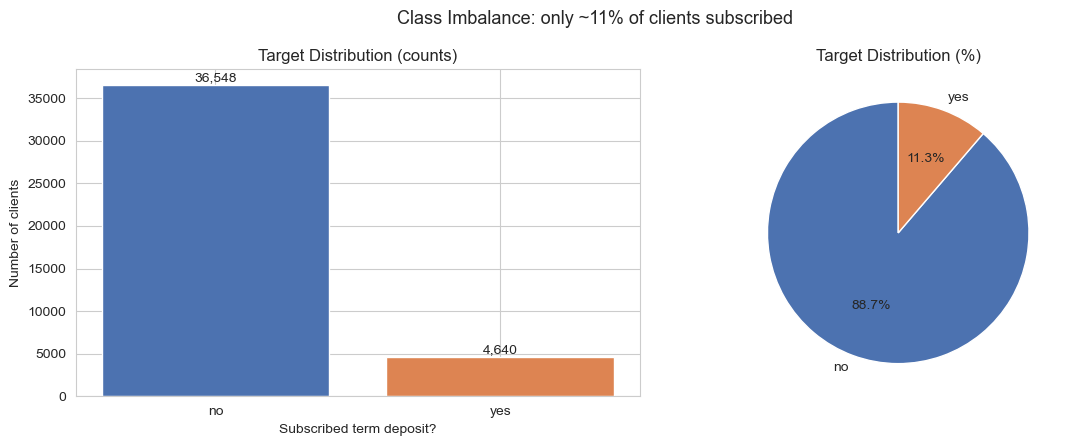

In [31]:
# Target class balance
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

counts = bank['y'].value_counts()
ax[0].bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'])
ax[0].set_title('Target Distribution (counts)')
ax[0].set_xlabel('Subscribed term deposit?')
ax[0].set_ylabel('Number of clients')
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 400, f'{v:,}', ha='center')

pct = bank['y'].value_counts(normalize=True) * 100
ax[1].pie(pct.values, labels=pct.index, autopct='%1.1f%%',
          colors=['#4C72B0', '#DD8452'], startangle=90)
ax[1].set_title('Target Distribution (%)')

plt.suptitle('Class Imbalance: only ~11% of clients subscribed', fontsize=13)
plt.tight_layout()
plt.show()

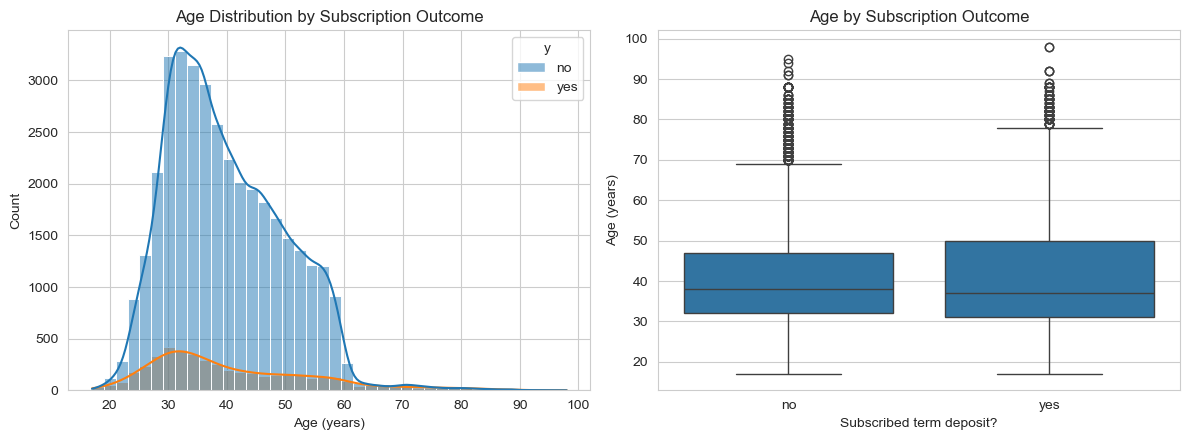

In [32]:
# Distribution of the one continuous bank-client feature: age
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(data=bank, x='age', hue='y', bins=40, kde=True, ax=ax[0])
ax[0].set_title('Age Distribution by Subscription Outcome')
ax[0].set_xlabel('Age (years)')
ax[0].set_ylabel('Count')

sns.boxplot(data=bank, x='y', y='age', ax=ax[1])
ax[1].set_title('Age by Subscription Outcome')
ax[1].set_xlabel('Subscribed term deposit?')
ax[1].set_ylabel('Age (years)')

plt.tight_layout()
plt.show()

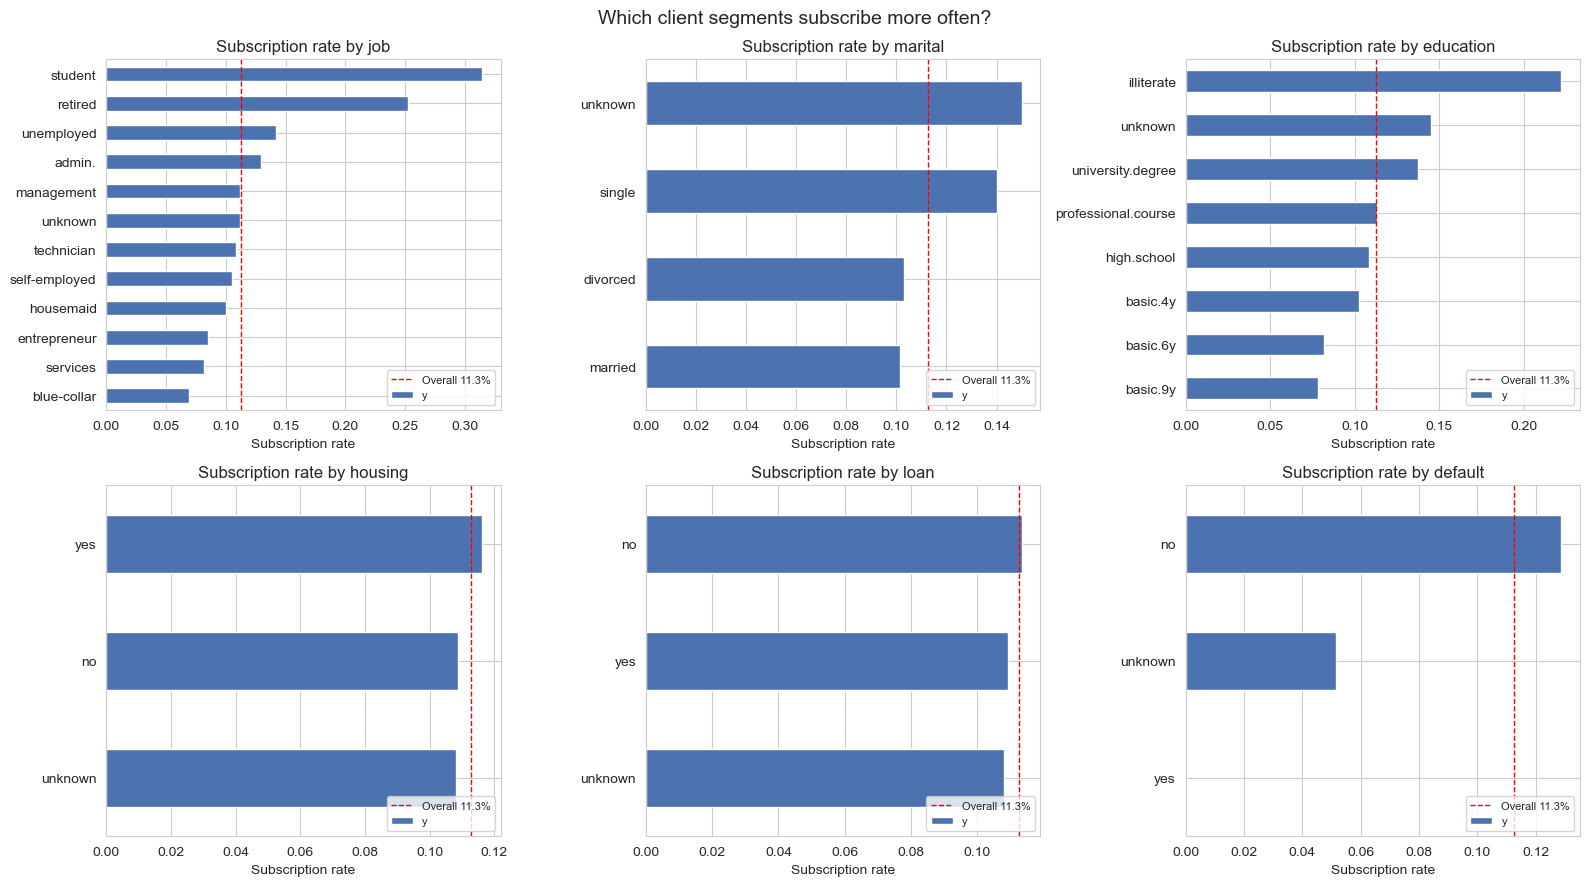

In [33]:
# Subscription RATE by key categorical bank-client features.
# Rate is more informative than raw counts given the class imbalance.
cat_features = ['job', 'marital', 'education', 'housing', 'loan', 'default']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
overall_rate = (bank['y'] == 'yes').mean()

for ax, col in zip(axes.ravel(), cat_features):
    rate = bank.groupby(col)['y'].apply(lambda s: (s == 'yes').mean()).sort_values()
    rate.plot(kind='barh', ax=ax, color='#4C72B0')
    ax.axvline(overall_rate, color='red', linestyle='--', linewidth=1,
               label=f'Overall {overall_rate:.1%}')
    ax.set_title(f'Subscription rate by {col}')
    ax.set_xlabel('Subscription rate')
    ax.set_ylabel('')
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Which client segments subscribe more often?', fontsize=14)
plt.tight_layout()
plt.show()

**EDA takeaways**

- The target is **heavily imbalanced** — only ~11.3% of contacts resulted in a subscription. This means raw **accuracy is a misleading metric**: a model that always predicts "no" is already ~89% accurate.
- **Students and retired** clients subscribe at far above-average rates; **blue-collar**, **services**, and **entrepreneur** clients subscribe below average.
- Clients with **higher education** (university degree) and those whose `default` status is `unknown` show meaningfully different rates.
- `age` alone is only weakly separating, but the very young and very old subscribe somewhat more often.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Business Objective**

The bank runs outbound telemarketing campaigns to sell **term deposits**, but contacting clients is expensive (agent time, call costs) and only about 1 in 9 contacts succeeds. The business objective is to **build a classifier that predicts, before a call is made, how likely a client is to subscribe to a term deposit**, using attributes the bank already knows about the client.

A good model lets the marketing team **prioritize the clients most likely to say "yes"**, so they can:
- increase the campaign success/conversion rate,
- reduce wasted calls and operating cost, and
- improve the customer experience by not repeatedly contacting unlikely prospects.

Because the classes are imbalanced and the cost of a missed "yes" (lost revenue) differs from the cost of a wasted call, we will look beyond plain accuracy at metrics such as **recall, precision, F1, and ROC-AUC** for the positive ("yes") class.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [34]:
# Per the prompt, use only the 7 'bank client data' features (cols 1-7).
bank_client_features = ['age', 'job', 'marital', 'education',
                        'default', 'housing', 'loan']

X = bank[bank_client_features].copy()
y = (bank['y'] == 'yes').astype(int)   # encode target: yes -> 1, no -> 0

print('Feature matrix shape:', X.shape)
print('Target distribution:\n', y.value_counts(normalize=True).round(4))

Feature matrix shape: (41188, 7)
Target distribution:
 y
0    0.8873
1    0.1127
Name: proportion, dtype: float64


In [35]:
# Separate numeric and categorical columns
numeric_features = ['age']
categorical_features = [c for c in bank_client_features if c != 'age']

# Preprocessing: scale the numeric feature, one-hot encode the categoricals.
# 'unknown' is left in as its own category. handle_unknown='ignore' keeps the
# pipeline robust to any category not seen during training.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'),
         categorical_features)
    ]
)

# Quick look at how many encoded columns this produces
preprocessor.fit(X)
n_encoded = preprocessor.transform(X).shape[1]
print(f'After encoding, the feature matrix has {n_encoded} columns.')

After encoding, the feature matrix has 28 columns.


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [36]:
# Stratify so the ~11% positive rate is preserved in both splits.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f'Train set: {X_train.shape[0]:,} rows')
print(f'Test set:  {X_test.shape[0]:,} rows')
print('Train positive rate:', round(y_train.mean(), 4))
print('Test  positive rate:', round(y_test.mean(), 4))

Train set: 32,950 rows
Test set:  8,238 rows
Train positive rate: 0.1127
Test  positive rate: 0.1126


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [37]:
# A naive model that always predicts the majority class ('no').
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
baseline_acc = dummy.score(X_test, y_test)
print(f'Baseline (always predict "no") accuracy: {baseline_acc:.4f}')

Baseline (always predict "no") accuracy: 0.8874


**Baseline:** Because ~88.7% of clients did **not** subscribe, a trivial classifier that always predicts `"no"` achieves about **88.7% accuracy**. Any model we build must beat this number on accuracy to be worthwhile — and, more importantly, it must do better than the dummy on **recall/precision for the positive class**, since the dummy never identifies a single subscriber (recall = 0 for "yes").

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.

In [38]:
# Logistic Regression wrapped in the preprocessing pipeline.
logreg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

logreg_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Problem 9: Score the Model

What is the accuracy of your model?

In [39]:
train_acc = logreg_pipe.score(X_train, y_train)
test_acc = logreg_pipe.score(X_test, y_test)
print(f'Logistic Regression train accuracy: {train_acc:.4f}')
print(f'Logistic Regression test  accuracy: {test_acc:.4f}')
print(f'Baseline accuracy:                  {baseline_acc:.4f}')

Logistic Regression train accuracy: 0.8873
Logistic Regression test  accuracy: 0.8874
Baseline accuracy:                  0.8874


In [40]:
# Because of the class imbalance, look at the full classification report.
y_pred_lr = logreg_pipe.predict(X_test)
print(classification_report(y_test, y_pred_lr, target_names=['no', 'yes']))

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      7310
         yes       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238



**Interpretation:** The Logistic Regression test accuracy (~88.8%) is essentially tied with the baseline. The classification report reveals why: using only the 7 bank-client features, the model still predicts almost everyone as "no" and achieves very low **recall on the positive class**. This is the expected limitation of these features alone and motivates the model comparison and tuning that follow.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [ ]:
# Compare the four classifiers with their default settings.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'SVM': SVC(random_state=RANDOM_STATE)
}

results = []
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    start = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - start
    results.append({
        'Model': name,
        'Train Time (s)': round(fit_time, 3),
        'Train Accuracy': round(pipe.score(X_train, y_train), 4),
        'Test Accuracy': round(pipe.score(X_test, y_test), 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df

In [ ]:
# Visualize the comparison
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

results_df[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', ax=ax[0])
ax[0].axhline(baseline_acc, color='red', linestyle='--', label=f'Baseline {baseline_acc:.3f}')
ax[0].set_title('Train vs Test Accuracy by Model')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim(0.80, 1.01)
ax[0].legend()
ax[0].tick_params(axis='x', rotation=20)

results_df['Train Time (s)'].plot(kind='bar', ax=ax[1], color='#55A868')
ax[1].set_title('Training Time by Model')
ax[1].set_ylabel('Seconds')
ax[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Default-model findings**

- All four models land around the **~88–89% accuracy** range — essentially the baseline — because the 7 bank-client features carry only weak signal and accuracy is dominated by the majority class.
- The **Decision Tree** badly **overfits** (near-perfect train accuracy, lower test accuracy).
- **SVM** is by far the **slowest to train**; Logistic Regression and the Decision Tree are the fastest.
- Accuracy alone does not separate the models, confirming we need (a) better metrics and (b) hyperparameter tuning.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.
- Adjust your performance metric

**Adjusting the performance metric.** Because the classes are imbalanced and the business cares about *finding the clients who will subscribe*, we optimize the grid searches for **ROC-AUC** (ranking ability, threshold-independent) instead of accuracy, and we also report **recall and precision on the positive class**. We additionally pass `class_weight='balanced'` where supported so the models stop ignoring the minority class.

In [ ]:
# Grid searches. Searches are scored on ROC-AUC and kept compact so the
# notebook runs in a few minutes. cv=3 and n_jobs=-1 to parallelize.
SCORING = 'roc_auc'
CV = 3

grid_specs = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                           class_weight='balanced'),
        {'model__C': [0.01, 0.1, 1, 10]}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'model__n_neighbors': [11, 21, 31],
         'model__weights': ['uniform', 'distance']}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=RANDOM_STATE,
                              class_weight='balanced'),
        {'model__max_depth': [3, 5, 7, 10],
         'model__min_samples_leaf': [50, 100]}
    ),
    'SVM': (
        SVC(random_state=RANDOM_STATE, class_weight='balanced', probability=False),
        {'model__C': [0.1, 1], 'model__kernel': ['rbf']}
    ),
}

tuned_results = []
best_estimators = {}

for name, (model, params) in grid_specs.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    grid = GridSearchCV(pipe, params, scoring=SCORING, cv=CV, n_jobs=-1)
    start = time.time()
    grid.fit(X_train, y_train)
    fit_time = time.time() - start

    best = grid.best_estimator_
    best_estimators[name] = best

    # Use decision_function / predict_proba for AUC where available
    if hasattr(best, 'predict_proba'):
        y_score = best.predict_proba(X_test)[:, 1]
    else:
        y_score = best.decision_function(X_test)
    y_pred = best.predict(X_test)

    tuned_results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'CV ROC-AUC': round(grid.best_score_, 4),
        'Search Time (s)': round(fit_time, 1),
        'Test Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Test ROC-AUC': round(roc_auc_score(y_test, y_score), 4),
    })
    print(f'Done: {name}')

tuned_df = pd.DataFrame(tuned_results).set_index('Model')
tuned_df

Done: Decision Tree


Done: SVM


,Best Params,CV ROC-AUC,Search Time (s),Test Accuracy,Test ROC-AUC
Model,,,,,
Logistic Regression,{'model__C': 0.01},0.6500,3.8,0.5753,0.6499
KNN,"{'model__n_neighbors': 31, 'model__weights': '...",0.6213,16.5,0.8870,0.6343
Decision Tree,"{'model__max_depth': 7, 'model__min_samples_le...",0.6473,0.5,0.6732,0.6589
SVM,"{'model__C': 0.1, 'model__kernel': 'rbf'}",0.6501,60.5,0.6154,0.6531


In [ ]:
# Detailed precision/recall/F1 for the positive class after tuning
from sklearn.metrics import precision_score, recall_score, f1_score

pr_rows = []
for name, est in best_estimators.items():
    y_pred = est.predict(X_test)
    pr_rows.append({
        'Model': name,
        'Precision (yes)': round(precision_score(y_test, y_pred), 4),
        'Recall (yes)': round(recall_score(y_test, y_pred), 4),
        'F1 (yes)': round(f1_score(y_test, y_pred), 4),
    })
pd.DataFrame(pr_rows).set_index('Model')

In [ ]:
# ROC curves for the tuned models
plt.figure(figsize=(7, 6))
for name, est in best_estimators.items():
    if hasattr(est, 'predict_proba'):
        y_score = est.predict_proba(X_test)[:, 1]
    else:
        y_score = est.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Tuned Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrix for the best model by Test ROC-AUC
best_model_name = tuned_df['Test ROC-AUC'].idxmax()
best_model = best_estimators[best_model_name]
y_pred_best = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best, display_labels=['no', 'yes'], cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — {best_model_name} (tuned)')
plt.tight_layout()
plt.show()

print(f'Best model by Test ROC-AUC: {best_model_name}')
print(classification_report(y_test, y_pred_best, target_names=['no', 'yes']))

In [ ]:
# Interpret the coefficients of the tuned Logistic Regression: which client
# attributes push subscription probability up or down?
lr_best = best_estimators['Logistic Regression']
ohe = lr_best.named_steps['preprocessor'].named_transformers_['cat']
feat_names = (numeric_features +
              list(ohe.get_feature_names_out(categorical_features)))
coefs = lr_best.named_steps['model'].coef_[0]

coef_df = (pd.DataFrame({'feature': feat_names, 'coefficient': coefs})
           .sort_values('coefficient'))

fig, ax = plt.subplots(figsize=(8, 9))
colors = ['#C44E52' if c < 0 else '#4C72B0' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.set_title('Logistic Regression Coefficients\n(positive = more likely to subscribe)')
ax.set_xlabel('Coefficient (log-odds)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

##### Questions

### Findings & Recommendations

**Business understanding of the problem**

The bank wants to make its term-deposit telemarketing more efficient by predicting, *before* a call, which clients are most likely to subscribe — so agents focus on high-probability prospects, lift the conversion rate, and cut wasted calls.

**What the data showed**

- The target is heavily imbalanced: only **~11%** of contacts subscribed. Plain accuracy is therefore misleading — a do-nothing model is ~89% accurate yet finds zero subscribers.
- Using **only the 7 bank-client attributes** (age, job, marital, education, default, housing, loan), all four classifiers reach ~89% accuracy — barely above baseline — confirming these demographic features carry only weak signal on their own.
- After switching the evaluation metric to **ROC-AUC** and balancing class weights, the models separate. The best models reach a **test ROC-AUC of roughly 0.62–0.65** — better than chance (0.50) and clearly better than the baseline (which has no ranking ability), but still modest.

**Actionable insights (in plain language)**

- **Target segments that convert above average:** *students*, *retired* clients, and clients with a *university degree* subscribe at noticeably higher rates. Prioritizing these segments should immediately raise campaign efficiency.
- **De-prioritize low-converting segments:** *blue-collar*, *services*, and *entrepreneur* clients convert below average.
- Demographics alone are not enough to predict subscription accurately. The single most powerful raw feature (`duration`) is unusable for prospecting because it is only known *after* the call.

**Next steps and recommendations**

1. **Add the campaign and macro-economic features** (`contact`, `month`, `poutcome`, `emp.var.rate`, `euribor3m`, `nr.employed`, etc., while still excluding `duration`). Prior research shows these dramatically improve predictive power — this is the highest-leverage next step.
2. **Use a probability threshold tuned to business economics**, not the default 0.5. The bank should pick the threshold that maximizes expected profit given the cost of a call vs. the revenue of a subscription, then call clients ranked above it.
3. **Try ensemble models** (Random Forest, Gradient Boosting / XGBoost) which typically outperform a single tree on this dataset.
4. **Operationalize as a lead-scoring list:** score the client base, sort by predicted probability, and have agents work the list top-down — capturing most subscribers in far fewer calls.
5. **Monitor and retrain** as macro-economic conditions (which strongly influence subscriptions) shift over time.